In [1]:
!pip install opencv-python pixellib

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 46.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 MB 44.3 MB/s eta 0:00:0000:0100:01
  DEPRECATION: Building 'fvcore' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` opt

In [3]:
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

print(cv2.__version__)

4.11.0


원본 고양이 이미지 크기: (1305, 1205, 3)


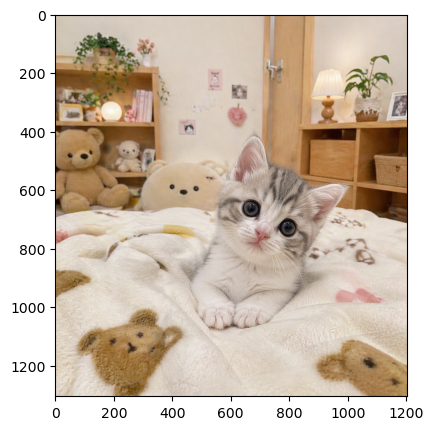

In [4]:
cat_img_path = "/home/jovyan/work/cat.png" 
cat_img = cv2.imread(cat_img_path)
cat_img = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)

print(f"원본 고양이 이미지 크기: {cat_img.shape}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cat_img)

plt.show()

In [5]:
model = deeplabv3_resnet101(pretrained=True).eval()

/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to /home/jovyan/.cache/torch/hub/checkpoints/deeplabv3_resnet101_coco-586e9e4e.pth


100%|██████████| 233M/233M [00:02<00:00, 102MB/s]  


In [6]:
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기 (고정)
    T.ToTensor(),
])


In [7]:
input_tensor = transform(cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)).unsqueeze(0)

In [8]:
%%time
with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

CPU times: user 9.24 s, sys: 368 ms, total: 9.6 s
Wall time: 12 s


In [9]:
# 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (cat_img.shape[1], cat_img.shape[0]), interpolation=cv2.INTER_NEAREST)


In [10]:
#pascalvoc 데이터의 라벨종류
LABEL_NAMES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep'
]
len(LABEL_NAMES)


18

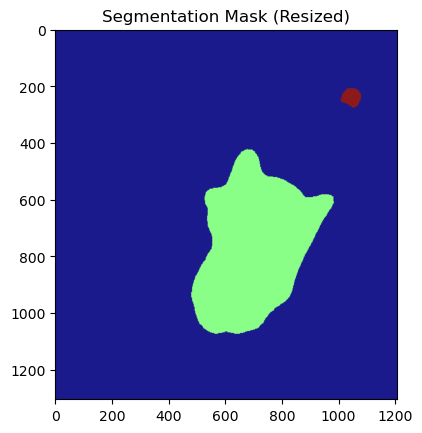

In [11]:

plt.imshow(output_predictions_resized, cmap="jet", alpha=0.9)
plt.title("Segmentation Mask (Resized)")
plt.show()

In [12]:
unique_classes = np.unique(output_predictions_resized)
unique_classes

for class_id in unique_classes:
    print(LABEL_NAMES[class_id])

background
cat
pottedplant


In [13]:

# 아래 코드를 이해하지 않아도 좋습니다
# PixelLib에서 그대로 가져온 코드입니다
# 주목해야 할 것은 생성 코드 결과물이예요!

#컬러맵 만들기
colormap = np.zeros((256, 3), dtype=int)
ind = np.arange(256, dtype=int)

for shift in reversed(range(8)):
    for channel in range(3):
        colormap[:, channel] |= ((ind >> channel) & 1) << shift
    ind >>= 3

colormap[:17]  # 생성한 18개의 컬러맵 출력 

array([[  0,   0,   0],
       [128,   0,   0],
       [  0, 128,   0],
       [128, 128,   0],
       [  0,   0, 128],
       [128,   0, 128],
       [  0, 128, 128],
       [128, 128, 128],
       [ 64,   0,   0],
       [192,   0,   0],
       [ 64, 128,   0],
       [192, 128,   0],
       [ 64,   0, 128],
       [192,   0, 128],
       [ 64, 128, 128],
       [192, 128, 128],
       [  0,  64,   0]])

In [14]:
colormap[8] #컬러맵 8에 해당하는 배열 출력 (pacalvoc에 LABEL_NAMES 8번째인 사람)

array([64,  0,  0])

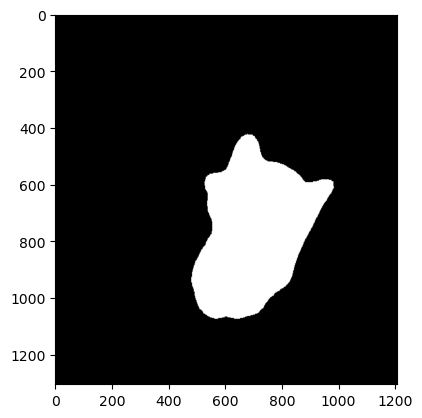

In [15]:
# output의 픽셀 별로 예측된 class가 사람이라면 1(True), 다르다면 0(False)이 됩니다
# 1과 0에 각각 255를 곱하였으므로 사람으로 예측된 픽셀은 255, 그렇지 않은 픽셀은 0
# cmap 값을 변경하면 다른 색상으로 확인이 가능함
seg_map = (output_predictions_resized == 8)  # 클래스 ID 8 (사람)
img_mask = seg_map.astype(np.uint8) * 255  # 255 값으로 변환
color_mask = cv2.applyColorMap(img_mask, cv2.COLORMAP_JET)

plt.imshow(img_mask, cmap='gray')  # 흑백으로 표시
plt.show()

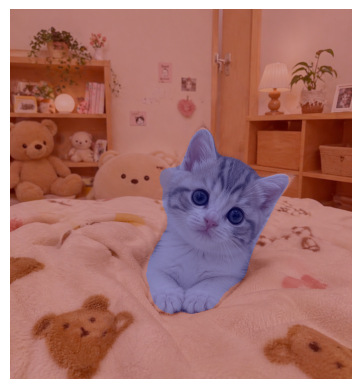

In [16]:
# 원본 이미지와 마스트를 적당히 합쳐봅니다
# 0.6과 0.4는 두 이미지를 섞는 비율입니다.

img_show = cv2.addWeighted(cat_img, 0.6, color_mask, 0.4, 0.0)

plt.imshow(img_show)   # ❗ cvtColor 제거
plt.axis('off')
plt.show()

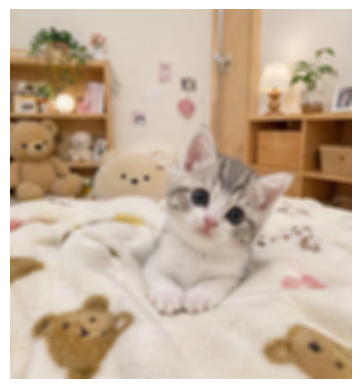

In [17]:
# (19,19)은 blurring kernel size를 뜻합니다
# 다양하게 바꿔보세요
img_orig_blur = cv2.blur(cat_img, (19, 19))

# plt.imshow(): 저장된 데이터를 이미지의 형식으로 표시한다.
# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_BGR2RGB: 원본이 BGR 순서로 픽셀을 읽다보니
# 이미지 색상 채널을 변경해야함 (BGR 형식을 RGB 형식으로 변경)

plt.imshow(img_orig_blur)   # ✅ 그대로 출력
plt.axis('off')
plt.show()

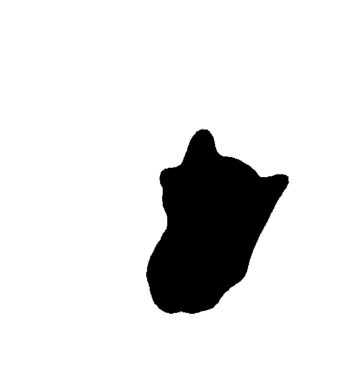

In [25]:
# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_BGR2RGB: 원본이 BGR 순서로 픽셀을 읽다보니
# 이미지 색상 채널을 변경해야함 (BGR 형식을 RGB 형식으로 변경)
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)

# cv2.bitwise_not(): 이미지가 반전됩니다. 배경이 0 사람이 255 였으나
# 연산을 하고 나면 배경은 255 사람은 0입니다.
img_bg_mask = cv2.bitwise_not(img_mask_color)

# cv2.bitwise_and()을 사용하면 배경만 있는 영상을 얻을 수 있습니다.
# 0과 어떤 수를 bitwise_and 연산을 해도 0이 되기 때문에
# 사람이 0인 경우에는 사람이 있던 모든 픽셀이 0이 됩니다. 결국 사람이 사라지고 배경만 남아요!
plt.imshow(img_bg_mask)   # ✅ 변환 없음
plt.axis('off')
plt.show()


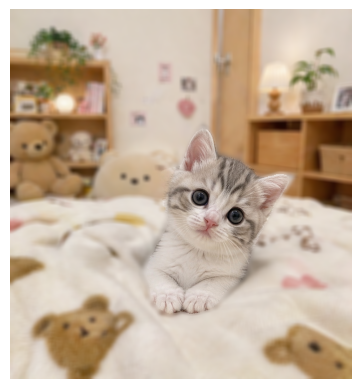

In [27]:
# np.where(조건, 참일때, 거짓일때)
# 세그멘테이션 마스크가 255인 부분만 원본 이미지 값을 가지고 오고
# 아닌 영역은 블러된 이미지 값을 사용합니다.
img_concat = np.where(img_mask_color==255, cat_img, img_orig_blur)
# plt.imshow(): 저장된 데이터를 이미지의 형식으로 표시한다.
# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_BGR2RGB: 원본이 BGR 순서로 픽셀을 읽다보니
# 이미지 색상 채널을 변경해야함 (BGR 형식을 RGB 형식으로 변경)
plt.imshow(img_concat)
plt.axis('off')
plt.show()


# 사막 배경 추가

원본 사막: (1024, 1536, 3)


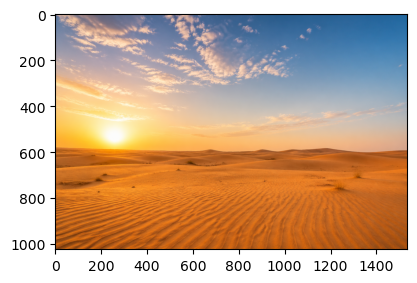

In [32]:
desert_img_path = "/home/jovyan/work/sandd.png"  # 네 사막 이미지 경로
desert_img = cv2.imread(desert_img_path)
desert_img = cv2.cvtColor(desert_img, cv2.COLOR_BGR2RGB)

print(f"원본 사막: {desert_img.shape}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(desert_img)

plt.show()


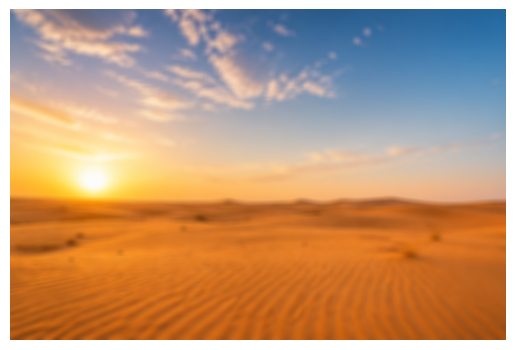

In [69]:
# (19,19)은 blurring kernel size를 뜻합니다
# 다양하게 바꿔보세요
img_orig_blur = cv2.blur(desert_img, (19, 19))

# plt.imshow(): 저장된 데이터를 이미지의 형식으로 표시한다.
# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_BGR2RGB: 원본이 BGR 순서로 픽셀을 읽다보니
# 이미지 색상 채널을 변경해야함 (BGR 형식을 RGB 형식으로 변경)

plt.imshow(img_orig_blur)   # ✅ 그대로 출력
plt.axis('off')
plt.show()

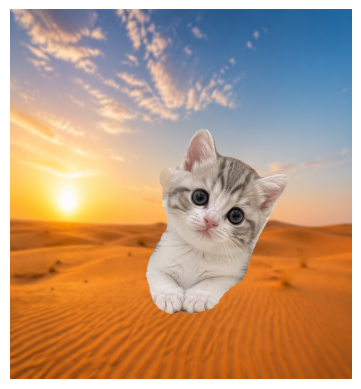

In [75]:
# 배경 = 사막
background = desert_img.copy()

# 고양이 부분만 추출
cat_only = np.where(img_mask_color == 255, cat_img, 0)

# 크기 맞추기 (배경을 고양이에 맞춤)
background_resized = cv2.resize(
    background,
    (cat_only.shape[1], cat_only.shape[0])
)

plt.imshow(img_concat)
plt.axis('off')
plt.show()

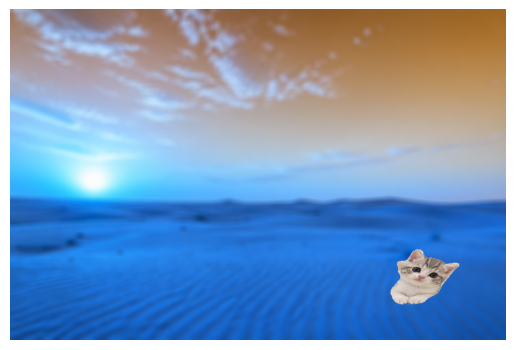

In [80]:
# 1. 배경
background = desert_img.copy()
h, w = background.shape[:2]

# 2. mask 
mask = cv2.cvtColor(img_mask_color, cv2.COLOR_BGR2GRAY)
_, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

# 이미지 불러오기 
cat_img = cv2.imread("/home/jovyan/work/cat.png")

# 3. resize
cat_resized = cv2.resize(cat_img, (w//3, h//3))
mask_resized = cv2.resize(mask, (w//3, h//3))

ch, cw = cat_resized.shape[:2]

# 4. 위치
x = w - cw - 50
y = h - ch - 50

# 5. blur 배경
background_blur = cv2.blur(background, (19, 19))

# 6. ROI
roi = background_blur[y:y+ch, x:x+cw]

# 7. mask split
mask_inv = cv2.bitwise_not(mask_resized)

bg_part = cv2.bitwise_and(roi, roi, mask=mask_inv)
fg_part = cv2.bitwise_and(cat_resized, cat_resized, mask=mask_resized)

# 8. 합성
dst = cv2.add(bg_part, fg_part)

background_blur[y:y+ch, x:x+cw] = dst

# 9. 출력
plt.imshow(cv2.cvtColor(background_blur, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [ ]:
사막 배경과 고양이 이미지를 이용해 블러 처리와 마스크 기반 합성을 시도하며 이미지 전처리 과정을 학습했습니다. 
이미지 크기 불일치, mask 채널 문제, 좌표 오류 등 다양한 에러를 해결하면서 OpenCV의 핵심 제약 조건에 대해 
학습하면서 이해하게 되었다. 그리고 고양이 이미지 위치 변경을 위해 ROI 기반 합성과 위치 이동 개념을 통해
이미지 편집을 시도하였으나 색이 깨지는 현상은 찾지 못했다. 